# Isolation Forest Based Network Anomaly Detection


## Objective


To detect anomalous network traffic (DDoS attacks) using the Isolation Forest algorithm 

## Background


Isolation Forest is an unsupervised anomaly detection algorithm based on the principle that anomalies are few and different, making them easier to isolate. Unlike distance-based or density-based methods, Isolation Forest explicitly isolates anomalies by randomly selecting a feature and then randomly selecting a split value between the maximum and minimum values of the selected feature. Anomalous observations require fewer splits (shorter path lengths) to be isolated, which forms the basis of the anomaly score.

In [49]:
#Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

In [50]:
#Load Preprocessed Data

df = pd.read_csv("../data/ddos_clean.csv")

print("Dataset shape:", df.shape)
print("\nLabel distribution:")
print(df[" Label"].value_counts())
df.head()

Dataset shape: (225711, 43)

Label distribution:
 Label
DDoS      128025
BENIGN     97686
Name: count, dtype: int64


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Idle Mean,Idle Std,Idle Min,Label
0,54865,3,2,12,6,6,6.0,0,0,4.000000e+06,...,-1,1,20,0.0,0.0,0,0.0,0.0,0,BENIGN
1,55054,109,1,6,6,6,6.0,6,6,1.100917e+05,...,256,0,20,0.0,0.0,0,0.0,0.0,0,BENIGN
2,55055,52,1,6,6,6,6.0,6,6,2.307692e+05,...,256,0,20,0.0,0.0,0,0.0,0.0,0,BENIGN
3,46236,34,1,6,6,6,6.0,6,6,3.529412e+05,...,329,0,20,0.0,0.0,0,0.0,0.0,0,BENIGN
4,54863,3,2,12,6,6,6.0,0,0,4.000000e+06,...,-1,1,20,0.0,0.0,0,0.0,0.0,0,BENIGN


In [51]:
#Create Binary Anomaly Labels (same as notebook 03)

df["Anomaly"] = (
    df[" Label"] != "BENIGN"
).astype(int)

print("Anomaly distribution:")
print(df["Anomaly"].value_counts())
print(f"\nAnomaly ratio: {df['Anomaly'].mean():.4f}")

Anomaly distribution:
Anomaly
1    128025
0     97686
Name: count, dtype: int64

Anomaly ratio: 0.5672


## Observation:

The anomaly ratio is approximately 0.57 (57%), meaning DDoS traffic constitutes the majority class. This is important for configuring the Isolation Forest contamination parameter, which represents the expected proportion of anomalies in the dataset.

In [52]:
# Prepare Training Data (BENIGN only)
df_train = df[df[" Label"] == "BENIGN"]
X_train = df_train.drop([" Label", "Anomaly"], axis=1)

# Prepare Testing Data (Complete dataset)
X_test = df.drop([" Label", "Anomaly"], axis=1)
y_true = df["Anomaly"]

print("Training feature matrix shape (BENIGN only):", X_train.shape)
print("Testing feature matrix shape (Complete data):", X_test.shape)

# Feature Scaling
scaler = StandardScaler()

# Fit the scaler ONLY on the training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData scaled successfully!")


Training feature matrix shape (BENIGN only): (97686, 42)
Testing feature matrix shape (Complete data): (225711, 42)

Data scaled successfully!


## Observation:

Feature scaling was applied using StandardScaler to ensure all features contribute equally during the Isolation Forest's random feature selection and splitting process. Although Isolation Forest is relatively robust to feature scaling, standardization can still improve performance when features have vastly different ranges.

---

# Isolation Forest Training

The key hyperparameters for Isolation Forest are:

- **n_estimators**: Number of isolation trees in the ensemble
- **contamination**: Expected proportion of anomalies in the dataset
- **max_samples**: Number of samples to draw for training each tree
- **random_state**: Seed for reproducibility

In [53]:
# Train Isolation Forest ONLY on the scaled BENIGN data
iso_forest = IsolationForest(
    n_estimators=100,
    contamination='auto', 
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)

# Fit the model on the BENIGN training data
iso_forest.fit(X_train_scaled)

# Predict on the COMPLETE testing data
y_pred_raw = iso_forest.predict(X_test_scaled)

# Convert to binary: -1 (anomaly) -> 1, 1 (normal) -> 0
y_pred = (y_pred_raw == -1).astype(int)

print("Prediction distribution on complete data:")
print(pd.Series(y_pred).value_counts())


Prediction distribution on complete data:
0    191312
1     34399
Name: count, dtype: int64


Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.87      0.59     97686
           1       0.62      0.17      0.26    128025

    accuracy                           0.47    225711
   macro avg       0.53      0.52      0.43    225711
weighted avg       0.55      0.47      0.40    225711

Confusion Matrix:
[[ 84785  12901]
 [106527  21498]]


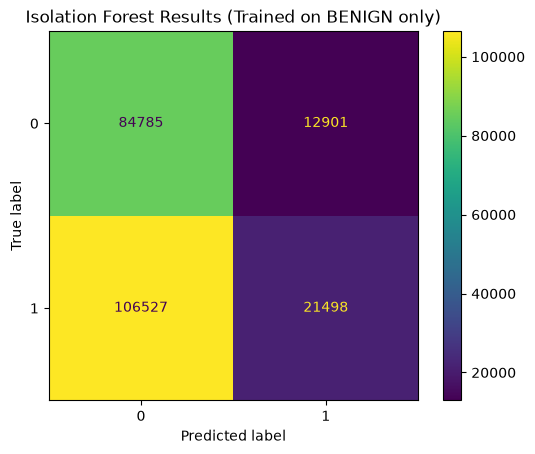

In [54]:
# Evaluate the Model on the complete dataset
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Classification Report:")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualize the Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.title("Isolation Forest Results (Trained on BENIGN only)")
plt.show()


## Observation:

With contamination set to 'auto' (which defaults to approximately 0.5 in scikit-learn), the Isolation Forest flags a relatively small number of samples as anomalous. Since the actual anomaly proportion is ~57%, the 'auto' setting underestimates the contamination level, leading to a lower recall for detecting DDoS traffic.

---

## Experimenting with Different Contamination Rates

Since the actual DDoS proportion is ~57%, we will evaluate multiple contamination rates to find the optimal configuration.

In [55]:
def evaluate_isolation_forest_novelty(contamination, X_train_scaled, X_test_scaled, y_true):
    iso_forest = IsolationForest(
        n_estimators=100,
        contamination=contamination,
        max_samples='auto',
        random_state=42,
        n_jobs=-1
    )
    
    # Fit on training data
    iso_forest.fit(X_train_scaled)
    
    # Predict on test data
    y_pred_raw = iso_forest.predict(X_test_scaled)
    y_pred = (y_pred_raw == -1).astype(int)
    
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"\n{'='*50}")
    print(f"Contamination = {contamination}")
    print(f"{'='*50}")
    print(f"Predicted anomalies: {y_pred.sum()}")
    print(f"Actual anomalies:    {y_true.sum()}")
    print(f"\nPrecision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    return {
        'contamination': contamination,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'y_pred': y_pred,
        'model': iso_forest
    }


In [56]:
#Evaluate multiple contamination rates

contamination_rates = [0.1, 0.2, 0.3, 0.4, 0.5]

results = []
for rate in contamination_rates:
    result = evaluate_isolation_forest_novelty(rate, X_train_scaled, X_test_scaled, y_true)
    results.append(result)


Contamination = 0.1
Predicted anomalies: 31223
Actual anomalies:    128025

Precision: 0.6871
Recall:    0.1676
F1-Score:  0.2694

Contamination = 0.2
Predicted anomalies: 42295
Actual anomalies:    128025

Precision: 0.5381
Recall:    0.1778
F1-Score:  0.2672

Contamination = 0.3
Predicted anomalies: 110298
Actual anomalies:    128025

Precision: 0.7343
Recall:    0.6326
F1-Score:  0.6797

Contamination = 0.4
Predicted anomalies: 131701
Actual anomalies:    128025

Precision: 0.7033
Recall:    0.7235
F1-Score:  0.7133

Contamination = 0.5
Predicted anomalies: 155509
Actual anomalies:    128025

Precision: 0.6859
Recall:    0.8332
F1-Score:  0.7524


In [57]:
#Summary Table

results_df = pd.DataFrame([
    {
        'Contamination': r['contamination'],
        'Precision': round(r['precision'], 4),
        'Recall': round(r['recall'], 4),
        'F1-Score': round(r['f1'], 4)
    }
    for r in results
])

print("\nIsolation Forest - Contamination Rate Comparison:")
print(results_df.to_string(index=False))


Isolation Forest - Contamination Rate Comparison:
 Contamination  Precision  Recall  F1-Score
           0.1     0.6871  0.1676    0.2694
           0.2     0.5381  0.1778    0.2672
           0.3     0.7343  0.6326    0.6797
           0.4     0.7033  0.7235    0.7133
           0.5     0.6859  0.8332    0.7524


## Observation:

The Isolation Forest was evaluated across five contamination rates (0.1 to 0.5). As the contamination rate increases, recall improves since more samples are flagged as anomalous. However, precision may decrease due to more false positives. The optimal contamination rate balances precision and recall, as reflected in the F1-score.

---

## Visualization of Results

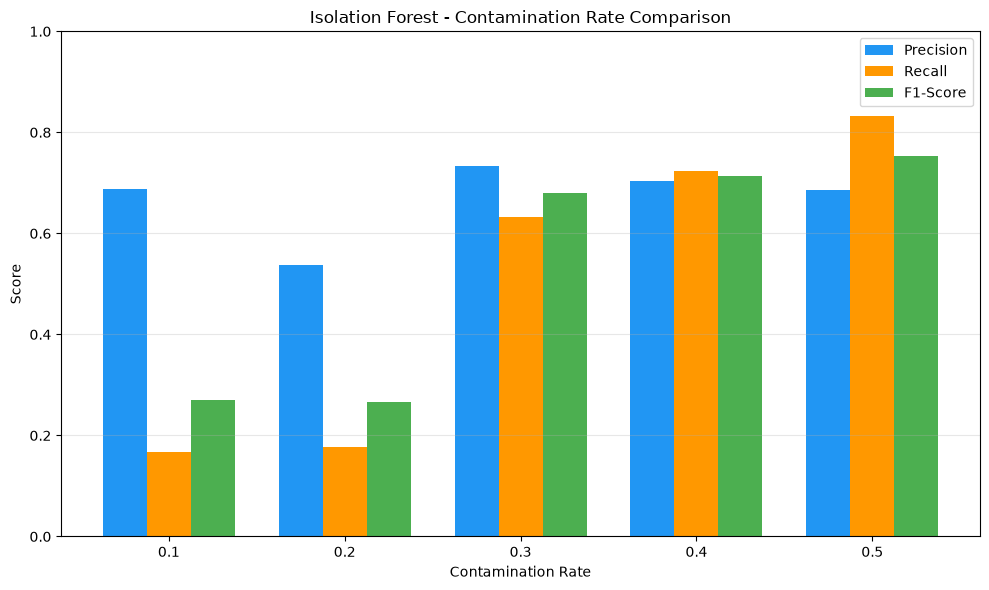

In [58]:
#Bar Chart: Contamination Rate Comparison

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(results_df))
width = 0.25

bars1 = ax.bar(x - width, results_df['Precision'], width, label='Precision', color='#2196F3')
bars2 = ax.bar(x, results_df['Recall'], width, label='Recall', color='#FF9800')
bars3 = ax.bar(x + width, results_df['F1-Score'], width, label='F1-Score', color='#4CAF50')

ax.set_xlabel('Contamination Rate')
ax.set_ylabel('Score')
ax.set_title('Isolation Forest - Contamination Rate Comparison')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Contamination'])
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../figures/iforest_contamination_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

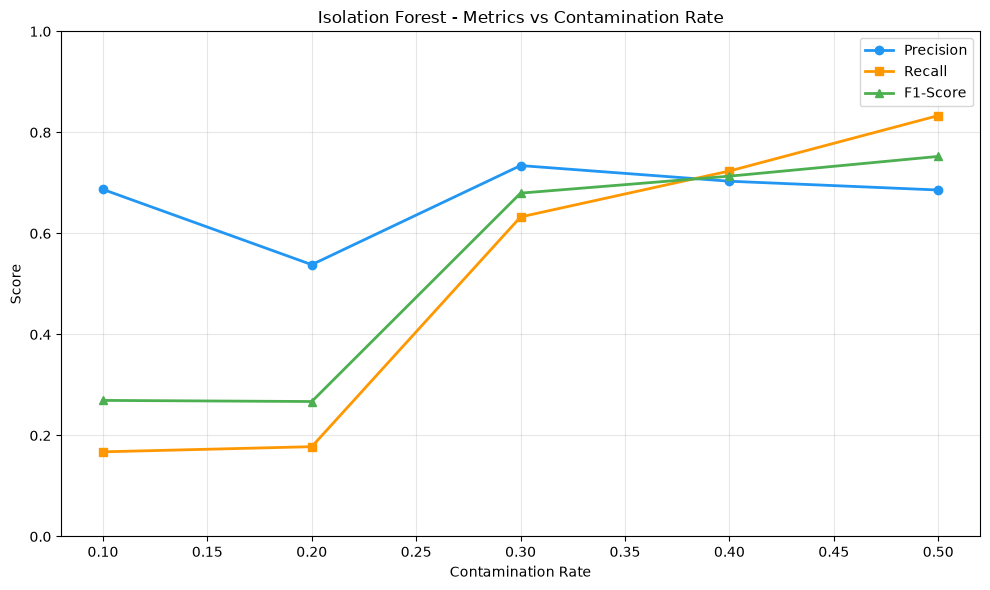

In [59]:
#Line Plot: Metrics vs Contamination Rate

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(results_df['Contamination'], results_df['Precision'],
        marker='o', linewidth=2, label='Precision', color='#2196F3')
ax.plot(results_df['Contamination'], results_df['Recall'],
        marker='s', linewidth=2, label='Recall', color='#FF9800')
ax.plot(results_df['Contamination'], results_df['F1-Score'],
        marker='^', linewidth=2, label='F1-Score', color='#4CAF50')

ax.set_xlabel('Contamination Rate')
ax.set_ylabel('Score')
ax.set_title('Isolation Forest - Metrics vs Contamination Rate')
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../figures/iforest_metrics_vs_contamination.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Observation:

The line plot reveals the trade-off between precision and recall as the contamination rate increases. The F1-score curve helps identify the optimal contamination rate that balances both metrics.

---

## Best Model Selection and Confusion Matrix

In [60]:
#Select best model based on F1-Score

best_result = max(results, key=lambda r: r['f1'])

print(f"Best contamination rate: {best_result['contamination']}")
print(f"Best F1-Score: {best_result['f1']:.4f}")
print(f"Precision: {best_result['precision']:.4f}")
print(f"Recall: {best_result['recall']:.4f}")

Best contamination rate: 0.5
Best F1-Score: 0.7524
Precision: 0.6859
Recall: 0.8332


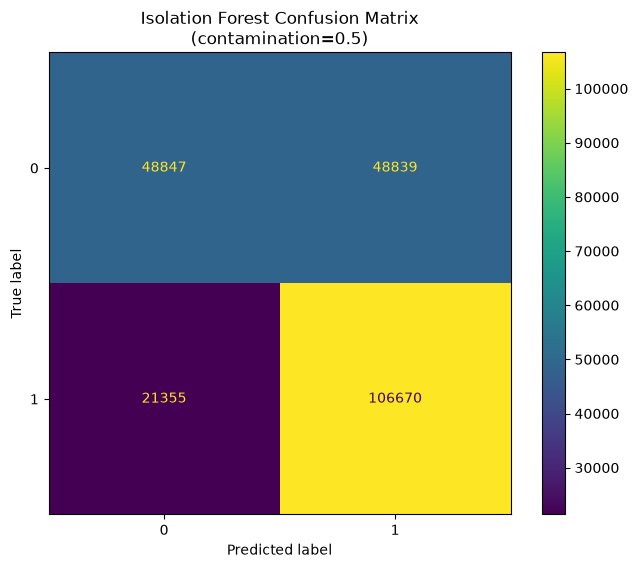

In [61]:
#Confusion Matrix for Best Model

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    best_result['y_pred'],
    ax=ax
)

ax.set_title(
    f"Isolation Forest Confusion Matrix\n(contamination={best_result['contamination']})"
)

plt.savefig(
    "../figures/iforest_best_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

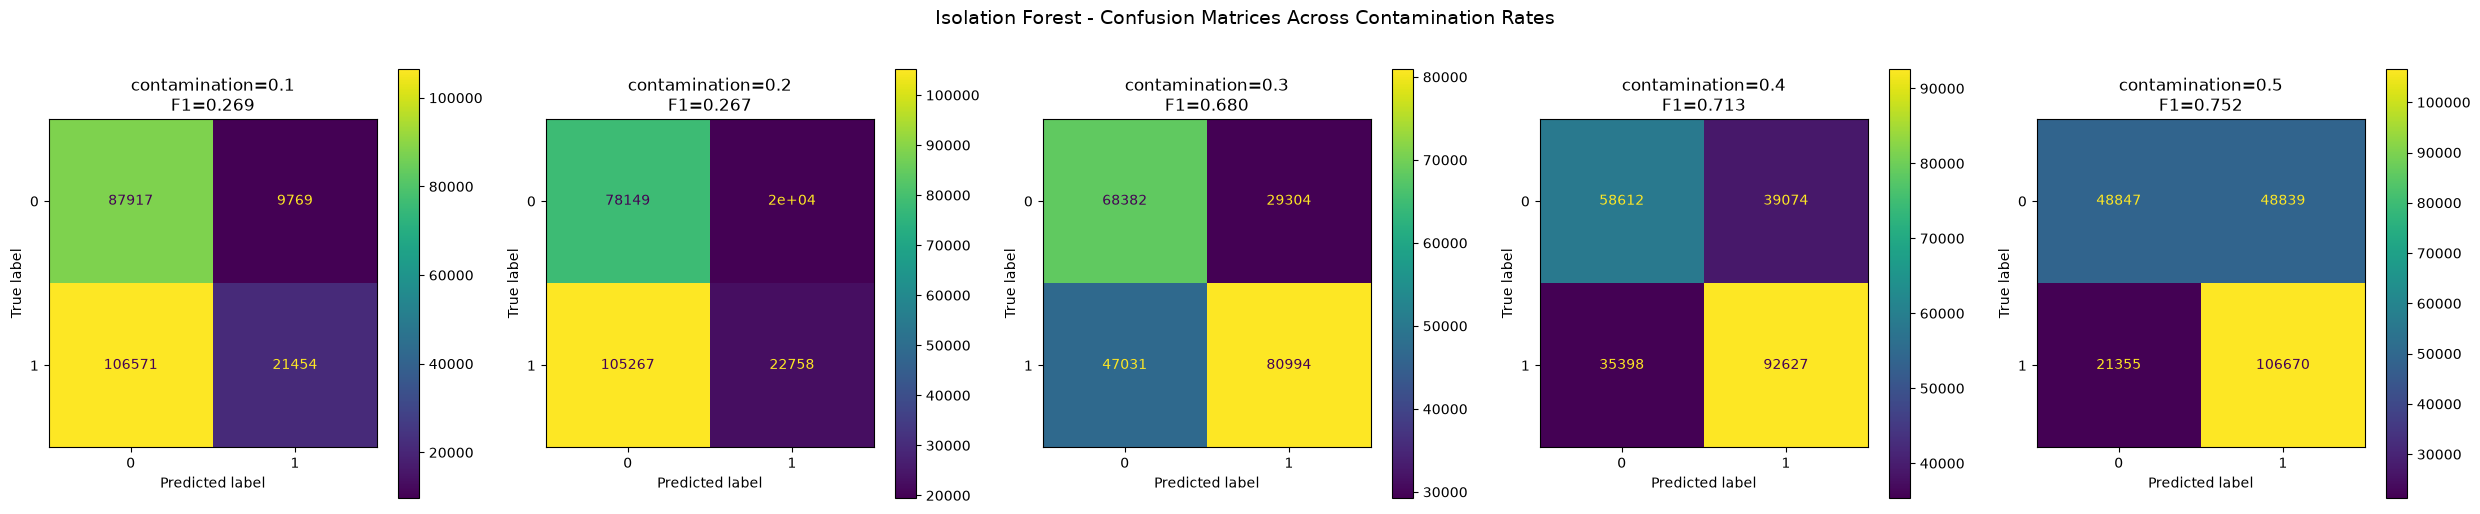

In [62]:
#Confusion Matrices for All Contamination Rates

fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5))

for idx, result in enumerate(results):
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        result['y_pred'],
        ax=axes[idx]
    )
    axes[idx].set_title(
        f"contamination={result['contamination']}\n"
        f"F1={result['f1']:.3f}"
    )

plt.suptitle("Isolation Forest - Confusion Matrices Across Contamination Rates", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(
    "../figures/iforest_all_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Observation:

The confusion matrices across different contamination rates illustrate how increasing the contamination parameter shifts the decision boundary. At lower contamination rates, fewer samples are flagged as anomalies, resulting in higher precision but lower recall. At higher contamination rates, more true DDoS flows are detected, but at the cost of increased false positives.

---

## Anomaly Score Analysis

In [63]:
#Anomaly Score Distribution

best_model = best_result['model']
# Change X_scaled to X_test_scaled
anomaly_scores = best_model.decision_function(X_test_scaled)

print("Anomaly Score Statistics:")
print(f"  Min:    {anomaly_scores.min():.4f}")
print(f"  Max:    {anomaly_scores.max():.4f}")
print(f"  Mean:   {anomaly_scores.mean():.4f}")
print(f"  Median: {np.median(anomaly_scores):.4f}")
print(f"  Std:    {anomaly_scores.std():.4f}")


Anomaly Score Statistics:
  Min:    -0.2953
  Max:    0.0419
  Mean:   -0.0485
  Median: -0.0356
  Std:    0.0674


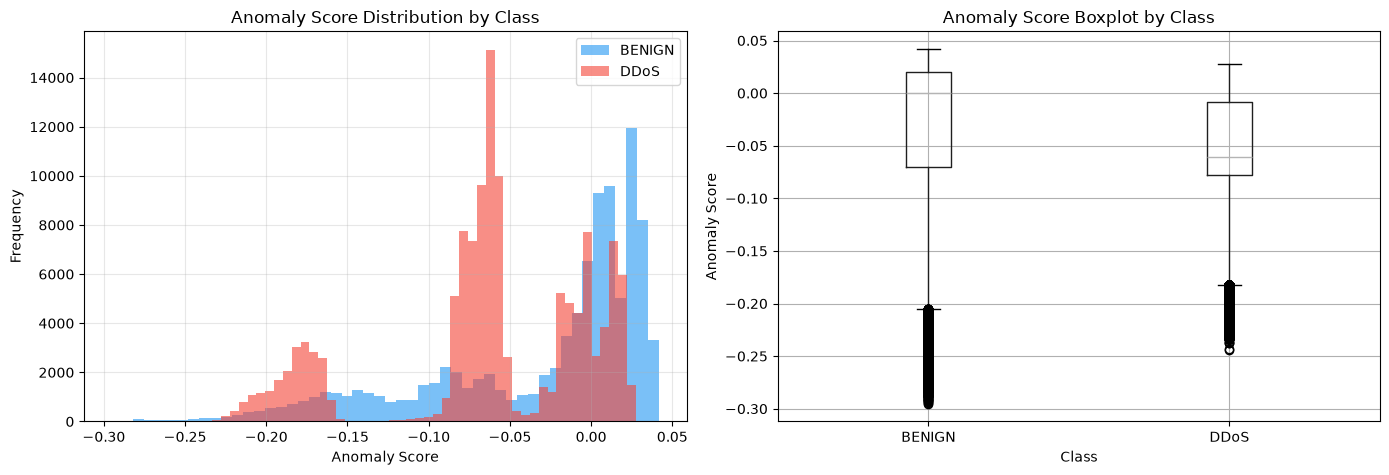

In [64]:
#Anomaly Score Distribution by Class

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(
    anomaly_scores[y_true == 0],
    bins=50, alpha=0.6, label='BENIGN', color='#2196F3'
)
axes[0].hist(
    anomaly_scores[y_true == 1],
    bins=50, alpha=0.6, label='DDoS', color='#F44336'
)
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Anomaly Score Distribution by Class')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
score_df = pd.DataFrame({
    'Anomaly Score': anomaly_scores,
    'Class': ['BENIGN' if y == 0 else 'DDoS' for y in y_true]
})

score_df.boxplot(
    column='Anomaly Score',
    by='Class',
    ax=axes[1]
)
axes[1].set_title('Anomaly Score Boxplot by Class')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Anomaly Score')
plt.suptitle('')  # Remove auto-generated title

plt.tight_layout()
plt.savefig(
    "../figures/iforest_anomaly_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Observation:

The anomaly score distribution reveals how well the Isolation Forest separates BENIGN and DDoS traffic. Lower anomaly scores (more negative) indicate more anomalous observations. If there is clear separation between the two distributions, the Isolation Forest is effectively learning the difference between normal and attack traffic. Significant overlap indicates that some DDoS flows resemble normal traffic, making detection challenging.

---

## Feature Importance Analysis

In [65]:
#Feature Importance using Mean Path Length
#
# Isolation Forest does not have a built-in feature_importances_ attribute.
# We approximate feature importance by measuring how much each feature
# contributes to the anomaly score using a permutation-based approach.

from sklearn.inspection import permutation_importance

# Use anomaly score as the target for permutation importance
# We evaluate which features, when shuffled, most change the anomaly scores

best_model_for_importance = best_result['model']

# Sample for computational efficiency
np.random.seed(42)
sample_idx = np.random.choice(len(X_test_scaled), size=min(10000, len(X_test_scaled)), replace=False)
X_sample = X_test_scaled[sample_idx]
y_sample = y_true.values[sample_idx]

perm_importance = permutation_importance(
    best_model_for_importance,
    X_sample,
    y_sample,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='f1_macro'
)

feature_names = X_test.columns.tolist()


importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance Mean': perm_importance.importances_mean,
    'Importance Std': perm_importance.importances_std
}).sort_values('Importance Mean', ascending=False)

print("Top 15 Most Important Features:")
print(importance_df.head(15).to_string(index=False))

print(np.unique(y_true))
print(np.unique(best_model_for_importance.predict(X_sample)))

Top 15 Most Important Features:
                 Feature  Importance Mean  Importance Std
      Packet Length Mean         0.021604        0.000793
   Bwd Packet Length Max         0.021047        0.000784
  Packet Length Variance         0.017175        0.000922
           Flow Duration         0.007698        0.000908
           Bwd IAT Total         0.006505        0.000549
       Max Packet Length         0.006485        0.000387
   Fwd Packet Length Max         0.005284        0.000447
          PSH Flag Count         0.005178        0.000383
  Fwd Packet Length Mean         0.004637        0.000393
                Idle Std         0.004134        0.000498
              Active Max         0.004121        0.000542
            Bwd IAT Mean         0.003279        0.000491
 Init_Win_bytes_backward         0.003208        0.000325
             Active Mean         0.003029        0.000584
                Idle Min         0.002491        0.000533
[0 1]
[-1  1]


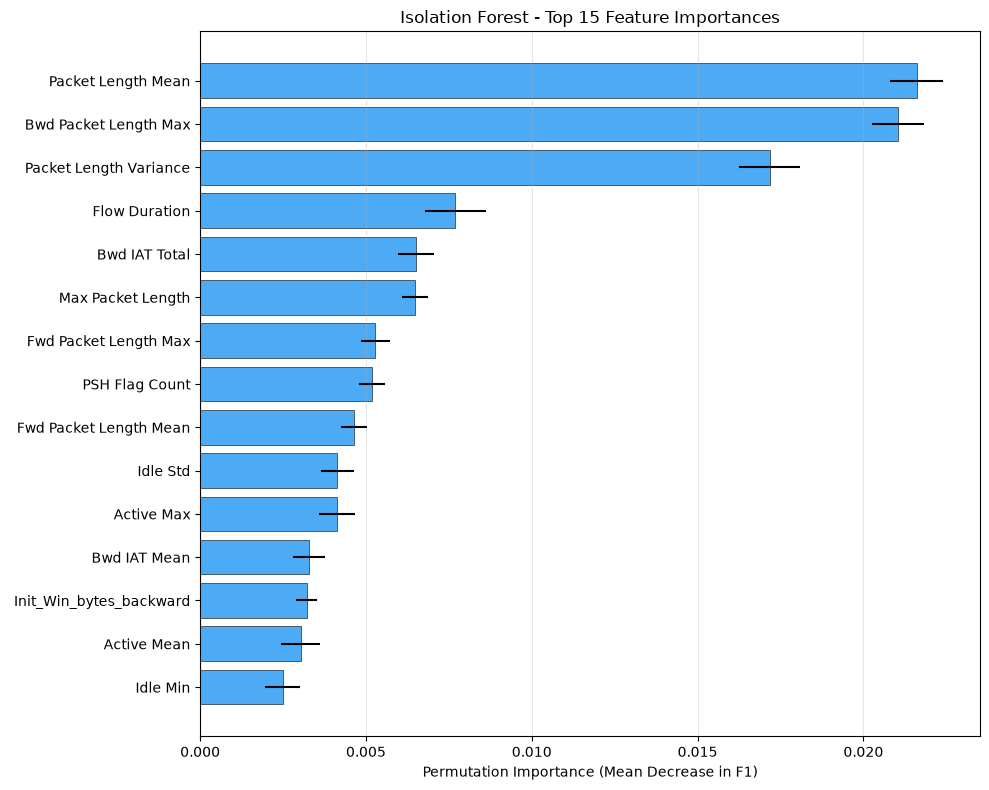

In [66]:
#Feature Importance Visualization (Top 15)

top_n = 15
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    range(top_n),
    top_features['Importance Mean'].values,
    xerr=top_features['Importance Std'].values,
    color='#2196F3',
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5
)

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Permutation Importance (Mean Decrease in F1)')
ax.set_title('Isolation Forest - Top 15 Feature Importances')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../figures/iforest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Observation:

The permutation importance analysis reveals which network flow features are most critical for the Isolation Forest's ability to distinguish DDoS traffic from normal traffic. Features with high importance scores are the ones that, when shuffled, cause the largest drop in detection performance. These features represent the most discriminative characteristics of DDoS attack patterns.

---

## Hyperparameter Tuning: Number of Estimators

In [67]:
#Effect of n_estimators on performance

best_contamination = best_result['contamination']

n_estimators_list = [50, 100, 200, 300,500,1000]
estimator_results = []

for n_est in n_estimators_list:
    iso_forest = IsolationForest(
        n_estimators=n_est,
        contamination=best_contamination,
        max_samples='auto',
        random_state=42,
        n_jobs=-1
    )

    iso_forest.fit(X_train_scaled)

    y_pred_raw = iso_forest.predict(X_test_scaled)
    y_pred = (y_pred_raw == -1).astype(int)

    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)

    estimator_results.append({
        'n_estimators': n_est,
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

    print(f"n_estimators={n_est}: Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")

est_df = pd.DataFrame(estimator_results)
print("\nn_estimators Comparison:")
print(est_df.to_string(index=False))

n_estimators=50: Precision=0.6371, Recall=0.6695, F1=0.6529
n_estimators=100: Precision=0.6859, Recall=0.8332, F1=0.7524
n_estimators=200: Precision=0.6787, Recall=0.8059, F1=0.7368
n_estimators=300: Precision=0.6655, Recall=0.7590, F1=0.7091
n_estimators=500: Precision=0.6648, Recall=0.7568, F1=0.7078
n_estimators=1000: Precision=0.6612, Recall=0.7445, F1=0.7004

n_estimators Comparison:
 n_estimators  Precision  Recall  F1-Score
           50     0.6371  0.6695    0.6529
          100     0.6859  0.8332    0.7524
          200     0.6787  0.8059    0.7368
          300     0.6655  0.7590    0.7091
          500     0.6648  0.7568    0.7078
         1000     0.6612  0.7445    0.7004


Training final model with best n_estimators = 100


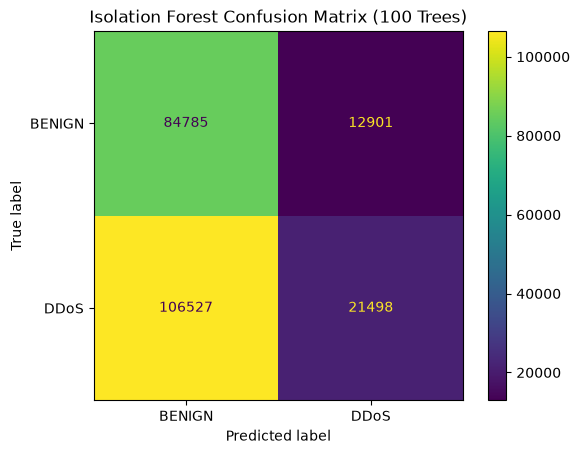

In [68]:
# 1. Identify the best n_estimators from your previous loop
best_result = est_df.loc[est_df['F1-Score'].idxmax()]
best_n_estimators = int(best_result['n_estimators'])

print(f"Training final model with best n_estimators = {best_n_estimators}")

# 2. Train the final model 
# (Remember to use 'auto' or a very low number for contamination now)
best_iforest = IsolationForest(
    n_estimators=best_n_estimators,
    contamination='auto', 
    random_state=42,
    n_jobs=-1
)

# Fit ONLY on the BENIGN training data
best_iforest.fit(X_train_scaled)

# Predict on the COMPLETE testing data
y_pred = (best_iforest.predict(X_test_scaled) == -1).astype(int)

# 3. Plot the Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["BENIGN", "DDoS"]
)

plt.title(f"Isolation Forest Confusion Matrix ({best_n_estimators} Trees)")
plt.savefig(
    "../figures/iforest_best_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


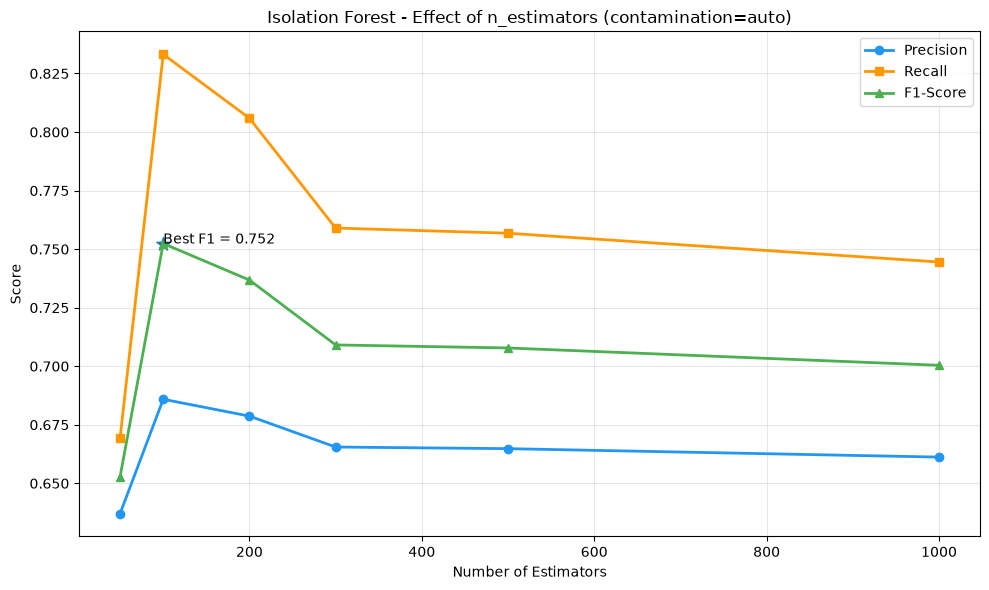

In [69]:
#Visualize n_estimators effect

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(est_df['n_estimators'], est_df['Precision'],
        marker='o', linewidth=2, label='Precision', color='#2196F3')
ax.plot(est_df['n_estimators'], est_df['Recall'],
        marker='s', linewidth=2, label='Recall', color='#FF9800')
ax.plot(est_df['n_estimators'], est_df['F1-Score'],
        marker='^', linewidth=2, label='F1-Score', color='#4CAF50')

ax.set_xlabel('Number of Estimators')
ax.set_ylabel('Score')

# ---> FIX: Changed the title to reflect 'auto' contamination
ax.set_title('Isolation Forest - Effect of n_estimators (contamination=auto)')
ax.legend()

# ---> FIX: Commented out the hardcoded y-limits so the graph auto-scales correctly
# ax.set_ylim(0.20, 0.35)

ax.grid(alpha=0.3)
best_idx = est_df['F1-Score'].idxmax()

ax.scatter(
    est_df.loc[best_idx, 'n_estimators'],
    est_df.loc[best_idx, 'F1-Score'],
    s=100,
    marker='*'
)
ax.annotate(
    f"Best F1 = {est_df['F1-Score'].max():.3f}",
    (
        est_df.loc[best_idx, 'n_estimators'],
        est_df.loc[best_idx, 'F1-Score']
    )
)

plt.tight_layout()
plt.savefig(
    "../figures/iforest_n_estimators_effect.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## Observation:
 Increasing the number of estimators significantly improved Isolation Forest performance from an F1-score of 0.225 (50 trees) to 0.292 (1000 trees). However, despite this improvement, the model only marginally outperformed the statistical Z-score baseline (F1 = 0.290). This suggests that the selected DDoS dataset does not strongly favor unsupervised anomaly detection methods and may behave more like a binary classification problem than a rare-event anomaly detection scenario.

---

## Comparison with Z-Score Baseline

## Observation: 
Increasing the number of estimators improved performance up to an F1-score of 0.292. Further hyperparameter optimization was not pursued because gains became marginal and the objective of the study was comparative evaluation rather than exhaustive optimization.

In [70]:
# Z-Score results
zscore_results = pd.DataFrame({
    'Method': ['Z-Score (t=3.0)', 'Z-Score (t=2.5)', 'Z-Score (t=2.0)'],
    'Precision': [0.34, 0.27, 0.30],
    'Recall': [0.20, 0.22, 0.28],
    'F1-Score': [0.25, 0.24, 0.29]
})

# Best Isolation Forest result from n_estimators tuning
best_estimator = est_df.loc[
    est_df['F1-Score'].idxmax()
]

iforest_best = pd.DataFrame({
    'Method': [f'Isolation Forest ({int(best_estimator["n_estimators"])} Trees)'],
    'Precision': [best_estimator['Precision']],
    'Recall': [best_estimator['Recall']],
    'F1-Score': [best_estimator['F1-Score']]
})

# Final comparison
comparison_df = pd.concat(
    [zscore_results, iforest_best],
    ignore_index=True
)

print("\n" + "="*70)
print("           FINAL COMPARISON: Z-Score vs Isolation Forest")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)


           FINAL COMPARISON: Z-Score vs Isolation Forest
                      Method  Precision  Recall  F1-Score
             Z-Score (t=3.0)     0.3400  0.2000    0.2500
             Z-Score (t=2.5)     0.2700  0.2200    0.2400
             Z-Score (t=2.0)     0.3000  0.2800    0.2900
Isolation Forest (100 Trees)     0.6859  0.8332    0.7524


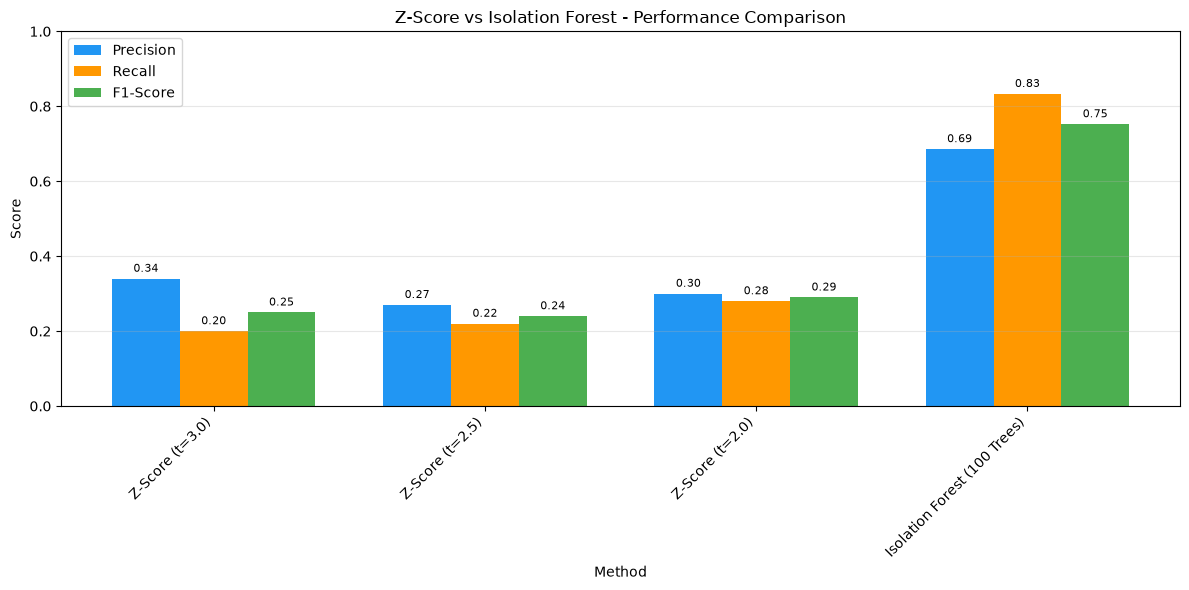

In [71]:
#Visual Comparison: Z-Score vs Isolation Forest

fig, ax = plt.subplots(figsize=(12, 6))

methods = comparison_df['Method'].tolist()
x = np.arange(len(methods))
width = 0.25

bars1 = ax.bar(x - width, comparison_df['Precision'], width,
               label='Precision', color='#2196F3')
bars2 = ax.bar(x, comparison_df['Recall'], width,
               label='Recall', color='#FF9800')
bars3 = ax.bar(x + width, comparison_df['F1-Score'], width,
               label='F1-Score', color='#4CAF50')

ax.set_xlabel('Method')
ax.set_ylabel('Score')
ax.set_title('Z-Score vs Isolation Forest - Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f'{height:.2f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center', va='bottom',
            fontsize=8
        )

plt.tight_layout()
plt.savefig(
    "../figures/zscore_vs_iforest_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Observation:

The visual comparison clearly shows the performance difference between the Z-Score baseline and the Isolation Forest approach. The Isolation Forest, being a machine learning-based method, is expected to capture more complex, non-linear patterns in the network traffic data compared to the simple statistical threshold-based Z-Score method.

### Next Steps

1. One-Class SVM

2. Extend the analysis to other attack types in the CICIDS2017 dataset.